# Refined Graph — San Diego August Temperature (1850–2014)

In [1]:
import ssl
import numpy as np
import pandas as pd
import xarray as xr
import zarr
import gcsfs
import matplotlib.pyplot as plt

ssl._create_default_https_context = ssl._create_unverified_context
xr.set_options(display_style='html')
plt.rcParams['figure.figsize'] = 12, 6
%matplotlib inline
%config InlineBackend.figure_format = 'retina'


In [2]:
df    = pd.read_csv('https://storage.googleapis.com/cmip6/cmip6-zarr-consolidated-stores.csv')
gcs   = gcsfs.GCSFileSystem(token='anon')

df_ta_ncar   = df.query("activity_id=='CMIP' & table_id=='Amon' & variable_id=='tas'"
                        " & experiment_id=='historical' & institution_id=='NCAR' & source_id=='CESM2'")
zstore       = df_ta_ncar.query("member_id=='r1i1p1f1'").zstore.values[0]
ds           = xr.open_zarr(gcs.get_mapper(zstore), consolidated=True)

sd_time_series = ds.tas.sel(lon=360-117.1611, lat=32.7157, method='nearest')


I0512 17:43:23.370299 40085812 fork_posix.cc:71] Other threads are currently calling into gRPC, skipping fork() handlers
I0512 17:43:23.393621 40085837 ev_poll_posix.cc:593] FD from fork parent still in poll list: fd(88, generation: 1)
I0512 17:43:23.393833 40085837 ev_poll_posix.cc:593] FD from fork parent still in poll list: fd(88, generation: 1)
I0512 17:43:23.393880 40085837 ev_poll_posix.cc:593] FD from fork parent still in poll list: fd(88, generation: 1)
I0512 17:43:23.393885 40085837 ev_poll_posix.cc:593] FD from fork parent still in poll list: fd(88, generation: 1)
I0512 17:43:23.393889 40085837 ev_poll_posix.cc:593] FD from fork parent still in poll list: fd(88, generation: 1)
I0512 17:43:23.393893 40085837 ev_poll_posix.cc:593] FD from fork parent still in poll list: fd(88, generation: 1)
I0512 17:43:23.393896 40085837 ev_poll_posix.cc:593] FD from fork parent still in poll list: fd(88, generation: 1)
I0512 17:43:23.393898 40085837 ev_poll_posix.cc:593] FD from fork parent s

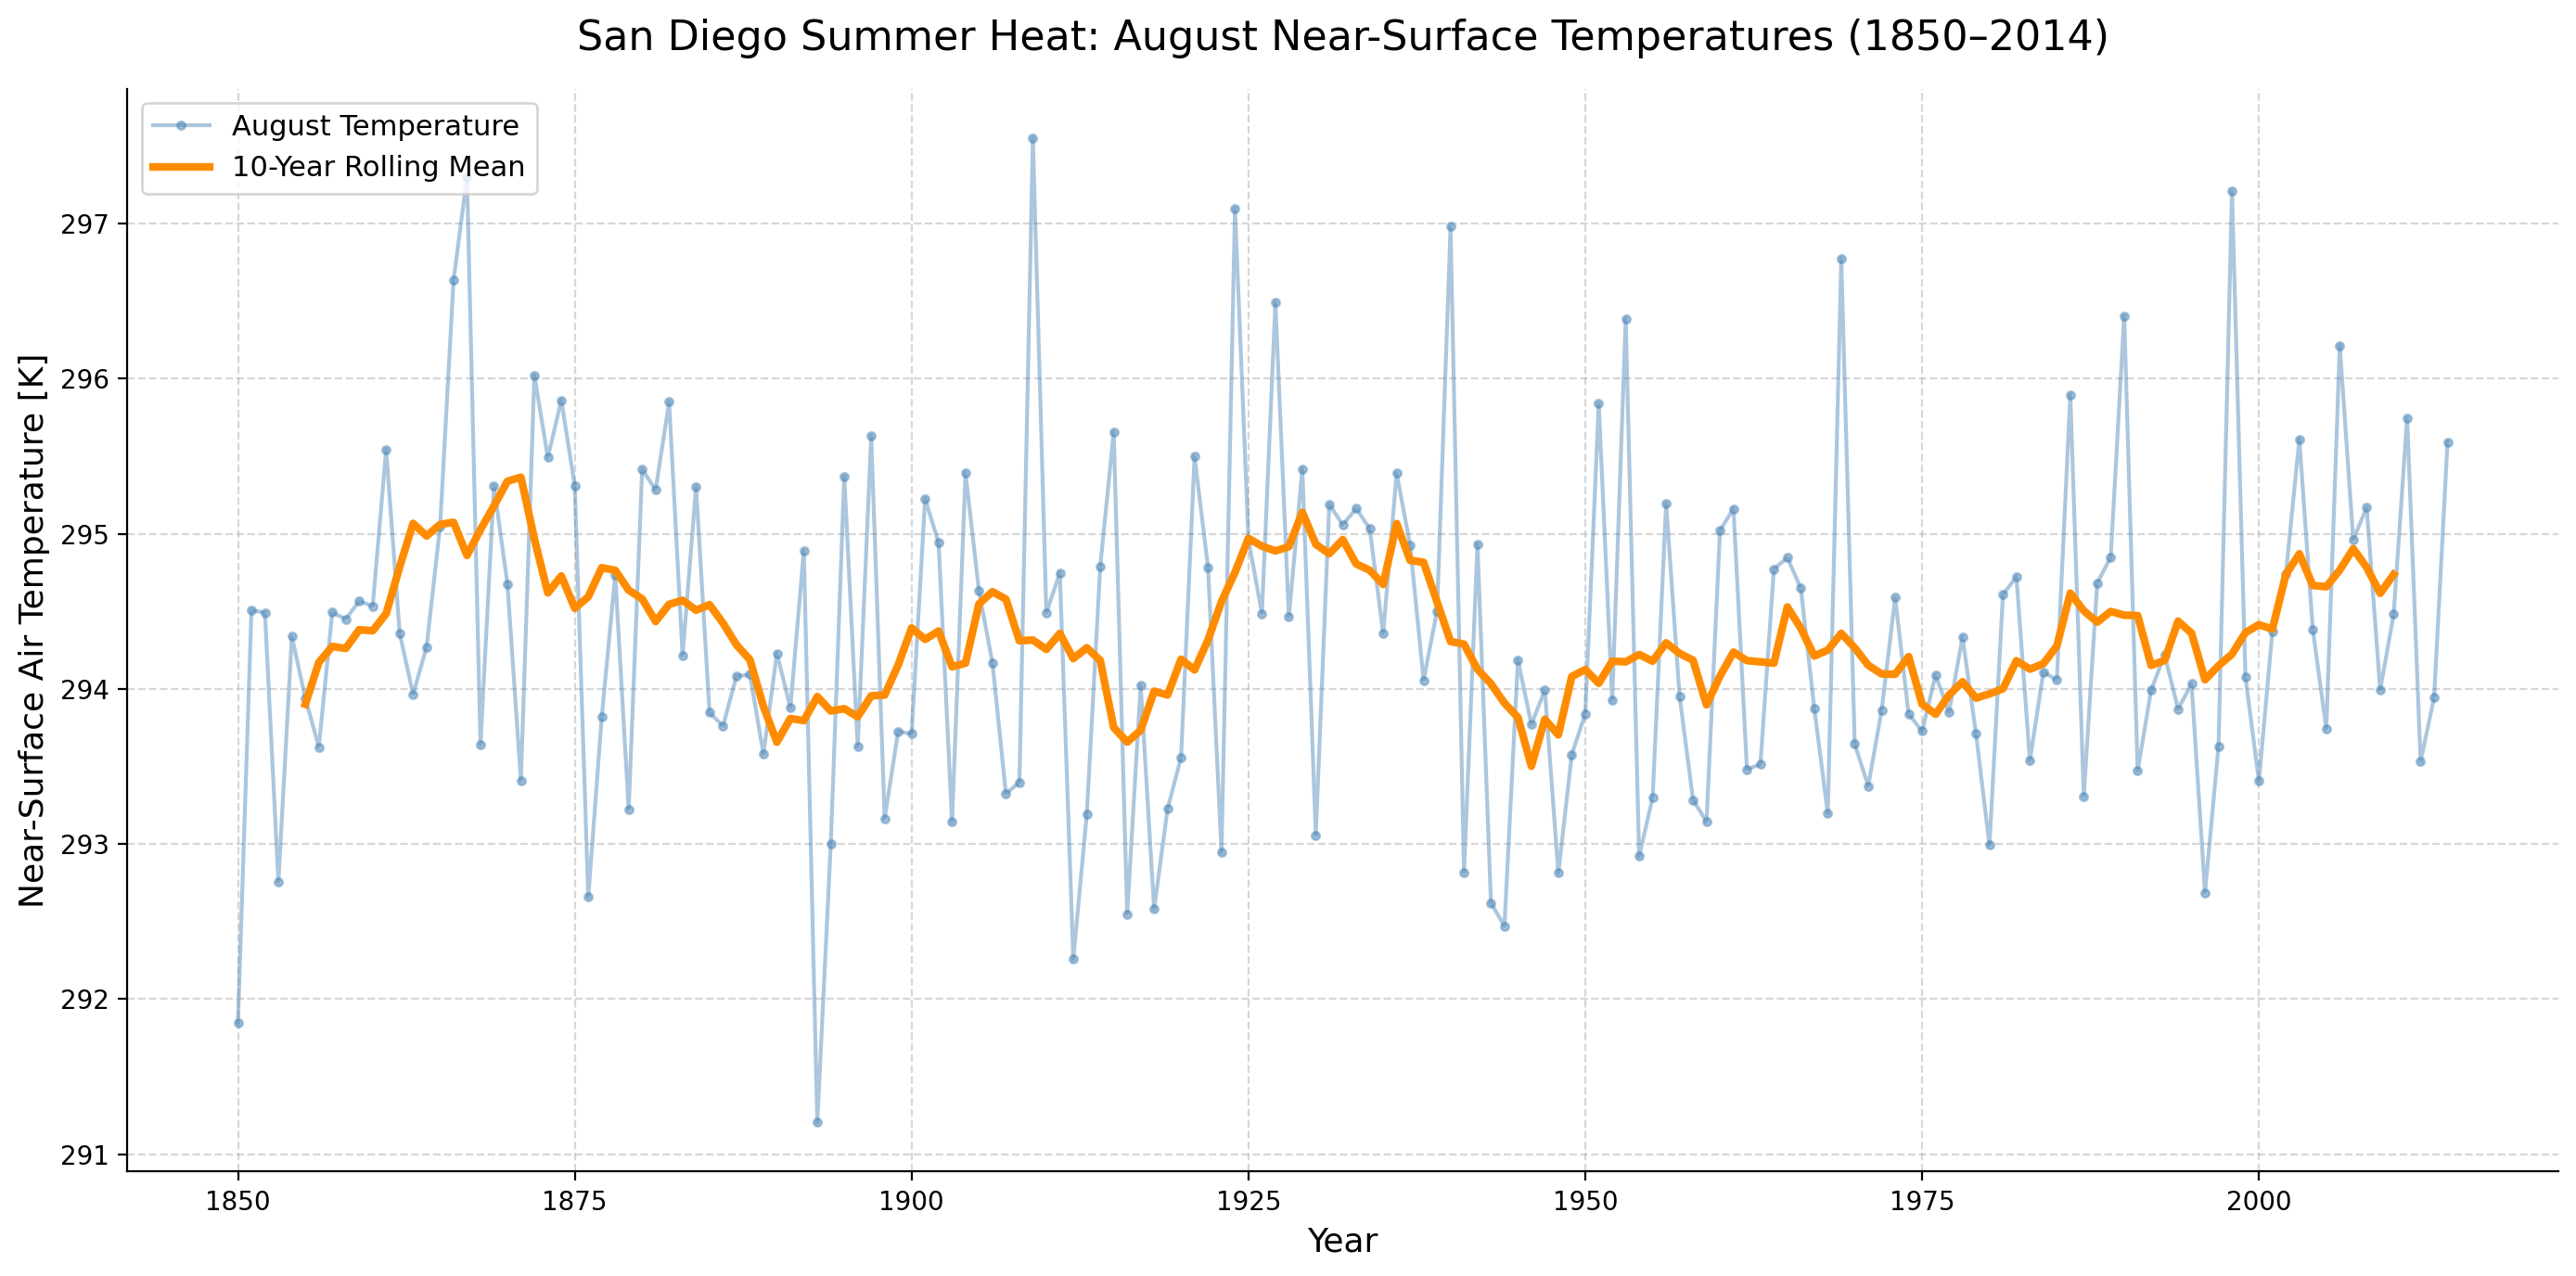

In [3]:
import matplotlib.pyplot as plt

sd_august = sd_time_series.sel(time=sd_time_series["time.month"] == 8)

sd_df = sd_august.to_dataframe(name="temperature").reset_index()
sd_df["year"] = sd_august["time.year"].values  # use xarray accessor — cftime-safe

sd_yearly = sd_df.groupby("year", as_index=False)["temperature"].mean()
sd_yearly["rolling_mean"] = sd_yearly["temperature"].rolling(window=10, center=True).mean()

fig, ax = plt.subplots(figsize=(14, 7))

ax.plot(
    sd_yearly["year"],
    sd_yearly["temperature"],
    color="steelblue",
    alpha=0.45,
    linewidth=1.5,
    marker="o",
    markersize=3,
    label="August Temperature"
)

ax.plot(
    sd_yearly["year"],
    sd_yearly["rolling_mean"],
    color="darkorange",
    linewidth=3,
    label="10-Year Rolling Mean"
)

ax.set_title(
    "San Diego Summer Heat: August Near-Surface Temperatures (1850–2014)",
    fontsize=16,
    pad=15
)
ax.set_xlabel("Year", fontsize=13)
ax.set_ylabel("Near-Surface Air Temperature [K]", fontsize=13)

ax.grid(True, linestyle="--", alpha=0.5)
ax.legend(loc="upper left", fontsize=11)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()


In [4]:
import os

# ── Export CSV for D3.js visualization ───────────────────────────
os.makedirs("data", exist_ok=True)

sd_august = sd_time_series.sel(time=sd_time_series["time.month"] == 8)
sd_df = sd_august.to_dataframe(name="temperature").reset_index()
sd_df["year"] = sd_august["time.year"].values   # cftime-safe

sd_yearly = sd_df.groupby("year", as_index=False)["temperature"].mean()
sd_yearly[["year", "temperature"]].to_csv("data/sd_august.csv", index=False)

print(f"Exported {len(sd_yearly)} rows → data/sd_august.csv")
sd_yearly.head()


Exported 165 rows → data/sd_august.csv


,year,temperature
0,1850,291.848175
1,1851,294.507690
2,1852,294.492035
3,1853,292.756500
4,1854,294.337708
